In [1]:
# Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import sem
import matplotlib.cm as cm
from scipy.stats import zscore
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')


In [2]:
def weibull_psychometric(x, alpha, beta, gamma, lambd):
    """
    Weibull psychometric function with lapse rate.

    Parameters:
    x : array_like
        Stimulus intensity (can be scalar or array).
    alpha : float
        Threshold (scale parameter).
    beta : float
        Slope (shape parameter).
    gamma : float
        Guess rate (lower asymptote).
    lambd : float
        Lapse rate (1 - upper asymptote).

    Returns:
    y : array_like
        Response probability for each x.
    """
    x = np.asarray(x)
    exponent = -1 * (x / alpha) ** beta
    y = gamma + (1 - gamma - lambd) * (1 - np.exp(exponent))
    return y


In [3]:
# Negative log-likelihood function
def neg_log_likelihood(params, x, n_trials, n_yes):
    alpha, beta, gamma, lambd = params
    p_yes = weibull_psychometric(x, alpha, beta, gamma, lambd)
    # Avoid log(0) by clipping probabilities
    p_yes = np.clip(p_yes, 1e-6, 1 - 1e-6)
    # Binomial log-likelihood
    log_likelihood = n_yes * np.log(p_yes) + (n_trials - n_yes) * np.log(1 - p_yes)
    return -np.sum(log_likelihood)

In [46]:
# REPETITION DETECTION
df_det_common = pd.read_csv('/Users/bastugb/Desktop/repetition_coherence_project/df_det_common.csv')
len(df_det_common['participant_id'].unique())

27

In [47]:
# Add cycle info
df_det_common['n_cycle'] = df_det_common['rt'] / df_det_common['unitdur']
len(df_det_common)

20412

OUTLIER ANALYSIS

In [12]:
anticipatory_mask = df_det_common['n_cycle'] >= 1  # this is anticipatory
df_det_common = df_det_common[anticipatory_mask]
len(df_det_common)

20396

In [13]:
df_det_common['is_outlier'] = False

# Group by percentage and unitdur
for (perc, dur), group in df_det_common.groupby(['percentage', 'unitdur']):
    Q1 = group['rt'].quantile(0.25)
    Q3 = group['rt'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # lower = group['n_tap_filtered'].quantile(0.05)
    # upper = group['n_tap_filtered'].quantile(0.95)
    # Mask for outliers
    outlier_mask = (group['rt'] < lower) | (group['rt'] > upper)
    # outlier_mask = (group['n_tap'] > upper)
    # Mark them in the original DataFrame
    df_det_common.loc[group.index, 'is_outlier'] = outlier_mask

# Filter out the outliers
df_det_clean = df_det_common[~df_det_common['is_outlier']].reset_index(drop=True)

num_outliers = len(df_det_common) - len(df_det_clean)
percentage_outliers = 100 * num_outliers / len(df_det_common)
print(f"{num_outliers} outliers removed ({percentage_outliers:.2f}% of total)")

706 outliers removed (3.46% of total)


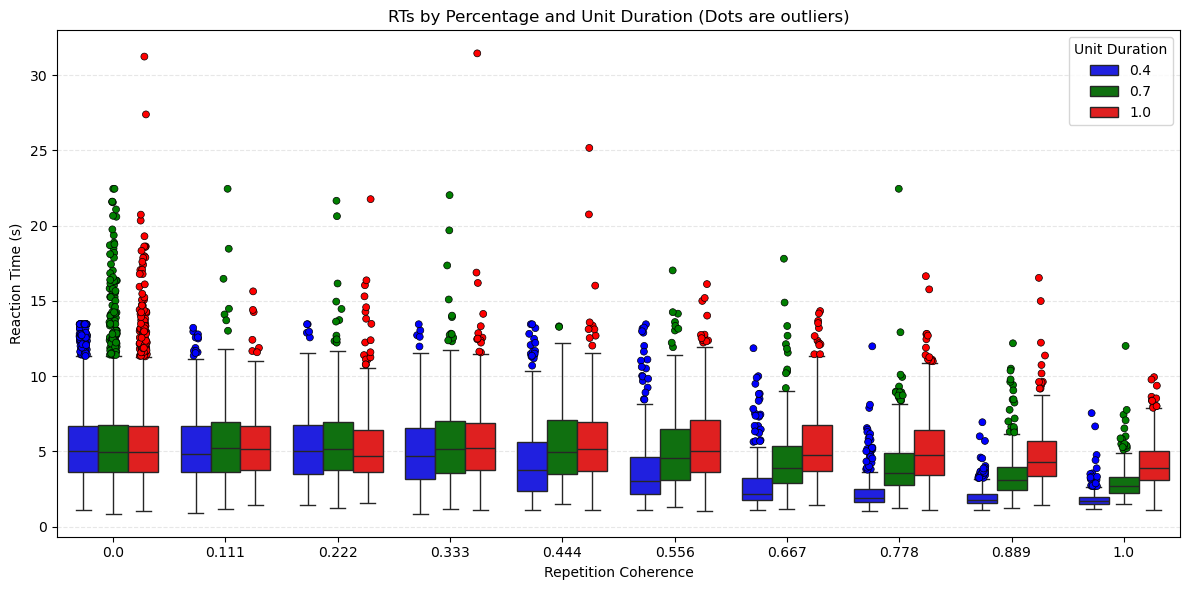

In [14]:
# Define custom color palette
custom_palette = {0.4: 'blue', 0.7: 'green', 1.0: 'red'}

plt.figure(figsize=(12, 6))

# Create a grouped boxplot using the custom palette
sns.boxplot(data=df_det_common, x='percentage', y='rt', hue='unitdur',
            palette=custom_palette, showfliers=False)

# Overlay outlier RTs using the same palette
outliers = df_det_common[df_det_common['is_outlier']]
sns.stripplot(data=outliers, x='percentage', y='rt', hue='unitdur',
              marker='o', dodge=True, palette=custom_palette,
              edgecolor='black', linewidth=0.5, size=5)

# Clean up the legend (to remove duplication from stripplot)
handles, labels = plt.gca().get_legend_handles_labels()
n_unique = df_det_common['unitdur'].nunique()
plt.legend(handles[:n_unique], labels[:n_unique], title='Unit Duration')

# Plot formatting
plt.title('RTs by Percentage and Unit Duration (Dots are outliers)')
plt.ylabel('Reaction Time (s)')
plt.xlabel('Repetition Coherence')
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Calculate mean accuracy per participant-block
perf = df_det_clean.groupby(['participant_id', 'block_idx'])['correct'].mean().reset_index()
perf.rename(columns={'correct': 'block_accuracy'}, inplace=True)

# Compute z-scores for block accuracy
perf['z_score'] = zscore(perf['block_accuracy'])

# Mark bad performance blocks
threshold = 3
perf['bad_performance'] = perf['z_score'].abs() > threshold

# Identify bad blocks
bad_blocks = perf[perf['bad_performance']][['participant_id', 'block_idx']]
print(bad_blocks)

    participant_id  block_idx
98              18          1


In [ ]:
# Merge and filter out bad blocks from the main data
df_det_no_outlier = df_det_clean.merge(bad_blocks, on=['participant_id', 'block_idx'], how='left', indicator=True)
df_det_no_outlier = df_det_no_outlier[df_det_no_outlier['_merge'] == 'left_only'].drop(columns=['_merge'])

# check how much data remains
print(f"Original trials: {len(df_det_clean)}")
print(f"Cleaned trials: {len(df_det_no_outlier)}")
print(f"difference: {len(df_det_clean) - len(df_det_no_outlier)}")



Original trials: 19690
Cleaned trials: 19585
difference: 105


In [17]:
# all individual's data
# all unit durations are merged
percentage_group_data_pid = df_det_clean.groupby(['percentage', 'participant_id']).agg(
    mean_yes=('actual_response', 'mean'),
    std_yes=('actual_response', 'std'),
    n_yes = ('actual_response', 'sum'),
    n_trial = ('actual_response', 'count'),
).reset_index()

In [18]:
# all conditions are averaged
# all durations are merged
percentage_group_data = df_det_clean.groupby(['percentage']).agg(
    mean_yes=('actual_response', 'mean'),
    std_yes=('actual_response', 'std'),
    n_yes = ('actual_response', 'sum'),
    n_trial = ('actual_response', 'count'),
).reset_index()

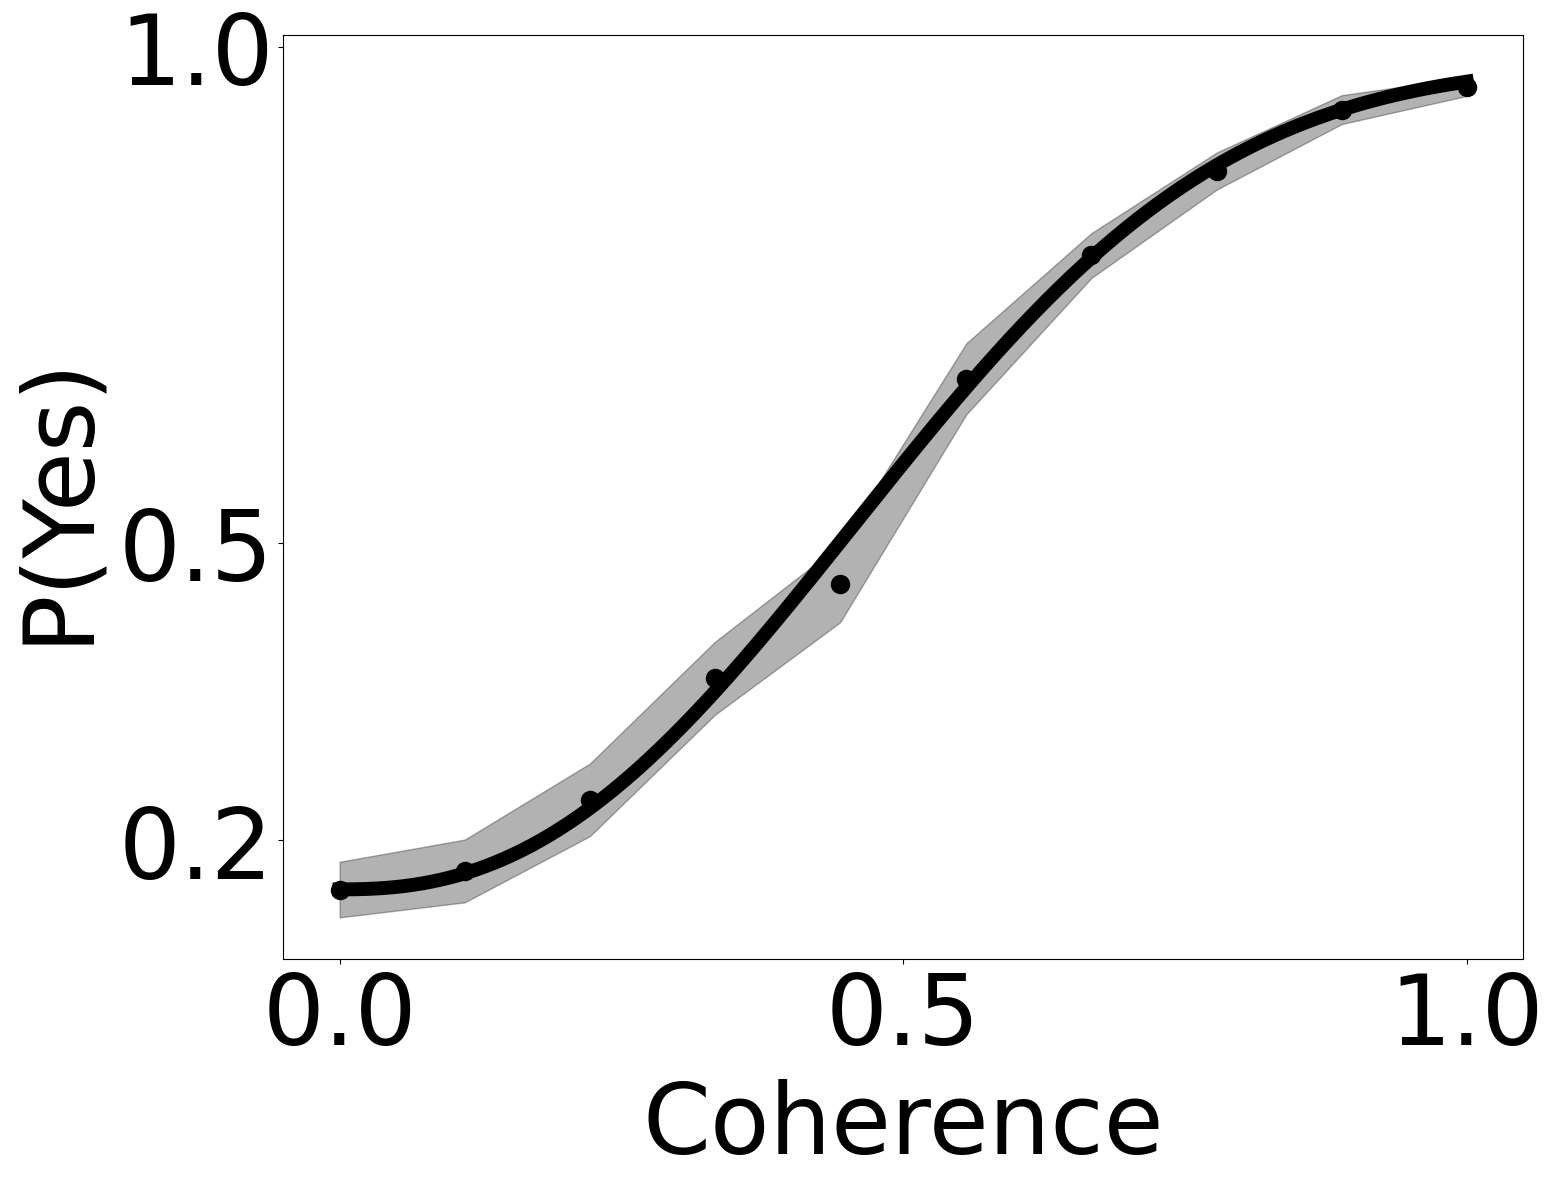

In [21]:
x_fit = np.linspace(0, 1, 500)
fig, ax = plt.subplots(figsize=(16, 12))

x_data_group = percentage_group_data['percentage'].values
y_data_group = percentage_group_data['n_yes'].values
n_trials_group = percentage_group_data['n_trial'].values

# # --- Initial parameters and bounds ---

init_params = [0.5, 3.0, 0.2, 0]  # alpha, beta, gamma, lambd
bounds = [(0.01, 1), (0.01, 50), (0, 1), (0, 1)]

res = minimize(neg_log_likelihood, init_params,
    args=(x_data_group, n_trials_group, y_data_group),
    bounds=bounds, method='Powell')

if res.success:
    alpha_fit, beta_fit, gamma_fit, lambd_fit = res.x

    y_fit = weibull_psychometric(x_fit, alpha_fit, beta_fit, gamma_fit, lambd_fit)

ax.plot(x_fit, y_fit, color='black', linewidth=10, label = 'All durations')


# --- Compute actual SEM of participant performance ---
grouped = (
    percentage_group_data_pid
    .groupby(['percentage'])
    .agg(avg=('mean_yes', 'mean'),
            std=('mean_yes', 'std'),
            n_participants=('mean_yes', 'count'))  # participant count
    .reset_index()
)
grouped['sem'] = grouped['std'] / np.sqrt(grouped['n_participants'])

# --- Plot only means as dots ---
ax.plot(grouped['percentage'], grouped['avg'], 'o', color = 'black', markersize=13, label=None)

# --- Shaded SEM area (actual performance variation) ---
ax.fill_between(grouped['percentage'],
                grouped['avg'] - grouped['sem'],
                grouped['avg'] + grouped['sem'], color = 'black', alpha=0.3)

# --- Final plot formatting ---
ax.set_xlabel('Coherence', fontsize=70, labelpad=10)
ax.set_ylabel('P(Yes)', fontsize=70, labelpad=10)
# ax.set_xlim(0, 1.02)
# ax.set_ylim(0.1, 1.02)
# ax.legend(title='')
plt.xticks([0, 0.5, 1], fontsize=70)
plt.yticks([0.2, 0.5, 1],fontsize=70)
# plt.tight_layout()
plt.show()


In [22]:
# averaged data but this time averaged by unitdur as well
summary_all = df_det_clean.groupby(['unitdur', 'percentage']).agg(
    mean_yes=('actual_response', 'mean'),
    std_yes=('actual_response', 'std'),
    n_yes = ('actual_response', 'sum'),
    n_trial = ('actual_response', 'count'),
).reset_index()

In [23]:
# this is to fit everyone 
summary_participant = df_det_no_outlier.groupby(['unitdur', 'percentage', 'participant_id']).agg(
    mean_yes=('actual_response', 'mean'),
    std_yes=('actual_response', 'std'),
    sum_yes = ('actual_response', 'sum'),
    n_trial = ('actual_response', 'count'),
).reset_index()

In [ ]:
# summary_participant.to_csv('detection_performance_for_r.csv', index=False)

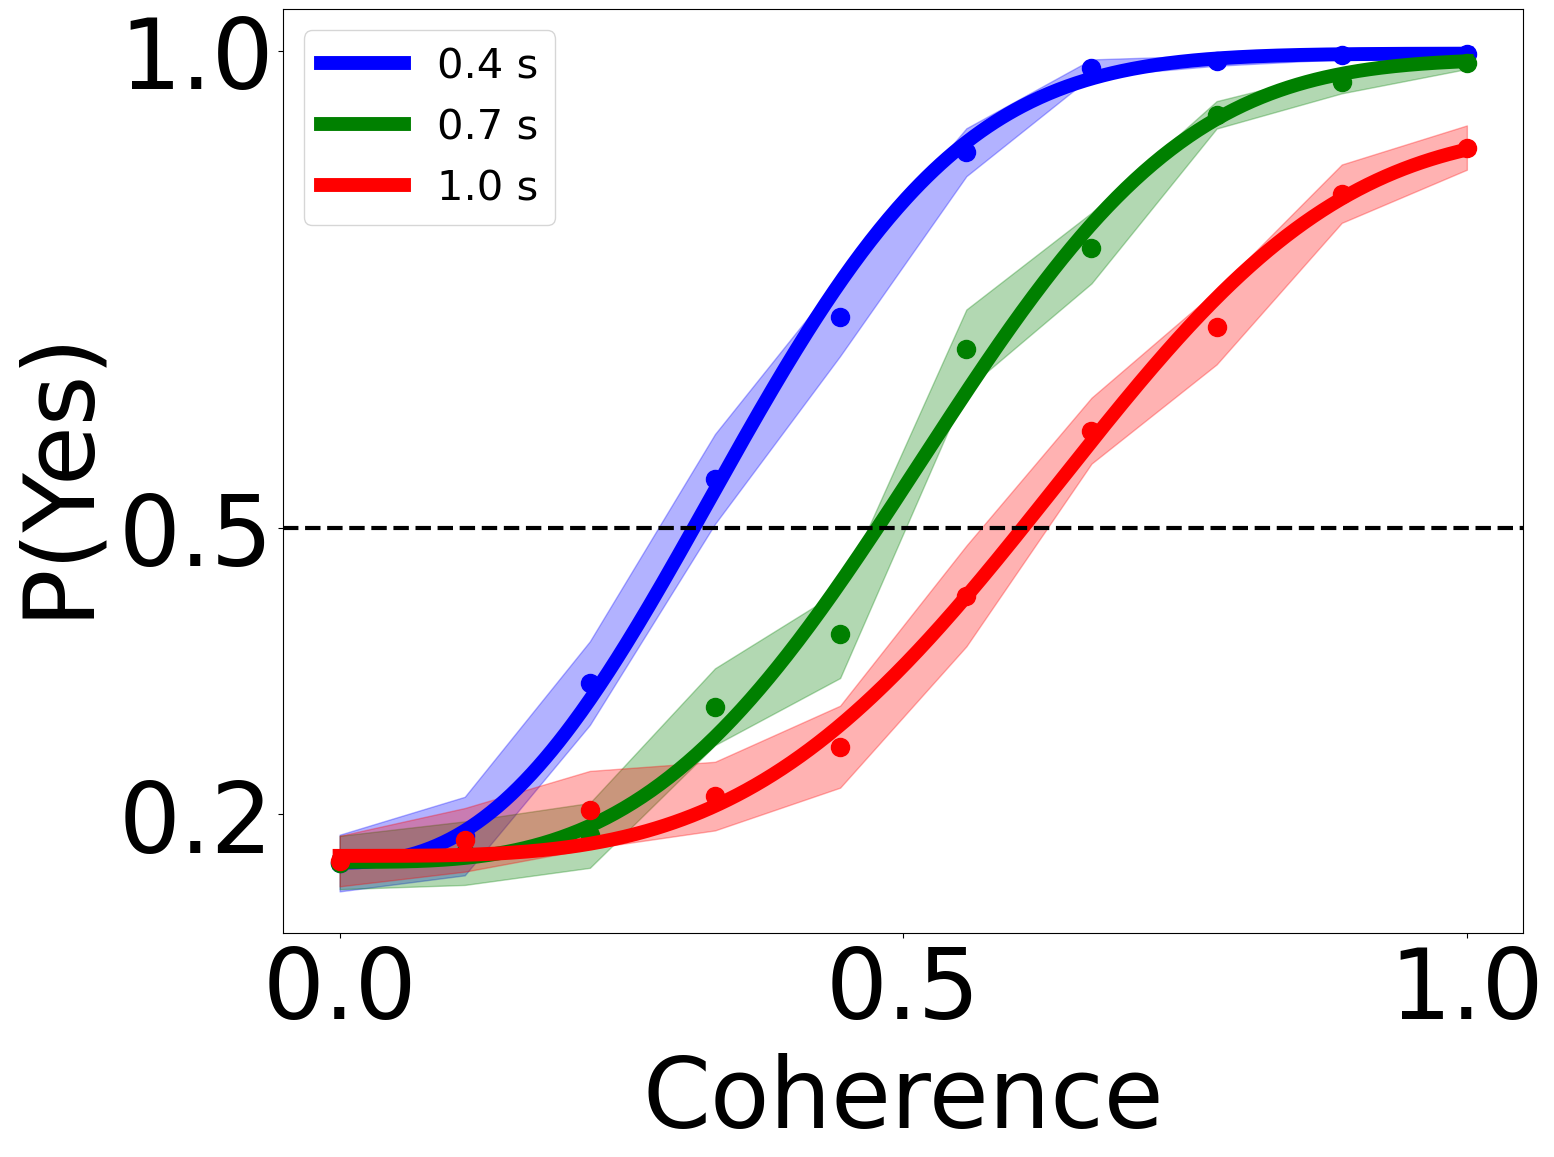

In [25]:
unit_durations = [0.4, 0.7, 1.0]
colors = ['blue', 'green', 'red']
x_fit = np.linspace(0, 1, 500)
fig, ax = plt.subplots(figsize=(16, 12))


all_fit_results = []
for unitdur, color in zip(unit_durations, colors):


    group_data = summary_all[summary_all['unitdur'] == unitdur]
    x_data_group = group_data['percentage'].values
    y_data_group = group_data['n_yes'].values
    n_trials_group = group_data['n_trial'].values

    # --- Initial parameters and bounds ---
    if unitdur == 0.4:
        init_params = [0.5, 3.0, 0.2, 0]  # last param = sigma
        bounds = [(0.01, 1), (0.01, 20), (0, 0.5), (0, 0.5)]
    elif unitdur == 0.7:
        init_params = [0.5, 3.0, 0.2, 0]
        bounds = [(0.01, 1), (0.01, 20), (0, 0.5), (0, 0.5)]
    elif unitdur == 1.0:
        init_params = [0.5, 3.0, 0.2, 0.1]
        bounds = [(0.01, 1), (0.01, 20), (0, 0.5), (0, 0.5)]


    # --- Fit Weibull to individual using MLE ---
    res = minimize(neg_log_likelihood, init_params,
            args=(x_data_group, n_trials_group, y_data_group),
            bounds=bounds, method='Powell')

    if res.success:
        alpha_fit, beta_fit, gamma_fit, lambd_fit = res.x

        all_fit_results.append({
            'unit_dur': unitdur,
            'alpha': alpha_fit,
            'beta': beta_fit,
            'gamma': gamma_fit,
            'lambda': lambd_fit
        })

        y_fit = weibull_psychometric(x_fit, alpha_fit, beta_fit, gamma_fit, lambd_fit)

    

    ax.plot(x_fit, y_fit, color=color, linewidth=10, label=f'{unitdur} s')
    

    # --- Compute actual SEM of participant performance ---
    grouped = (
        summary_participant[summary_participant['unitdur'] == unitdur]
        .groupby(['percentage'])
        .agg(avg_yes=('mean_yes', 'mean'),
             std_yes=('mean_yes', 'std'),
             n_participants=('mean_yes', 'count'))  # participant count
        .reset_index()
    )
    grouped['sem_yes'] = grouped['std_yes'] / np.sqrt(grouped['n_participants'])

    # --- Plot only means as dots ---
    ax.plot(grouped['percentage'], grouped['avg_yes'], 'o',
            color=color, markersize=13, label=None)

    # --- Shaded SEM area (actual performance variation) ---
    ax.fill_between(grouped['percentage'],
                    grouped['avg_yes'] - grouped['sem_yes'],
                    grouped['avg_yes'] + grouped['sem_yes'],
                    color=color, alpha=0.3)

# --- Final plot formatting ---
ax.set_xlabel('Coherence', fontsize=70, labelpad = 10)
ax.set_ylabel('P(Yes)', fontsize=70, labelpad=10)
ax.axhline(y=0.5, color='black', linestyle='--', linewidth=3)
# ax.set_xlim(0, 1.02)
# ax.set_ylim(0.1, 1.02)
ax.legend(title='', fontsize = 30)
plt.xticks([0, 0.5, 1], fontsize=70)
plt.yticks([0.2, 0.5, 1],fontsize=70)
# plt.tight_layout()
plt.show()


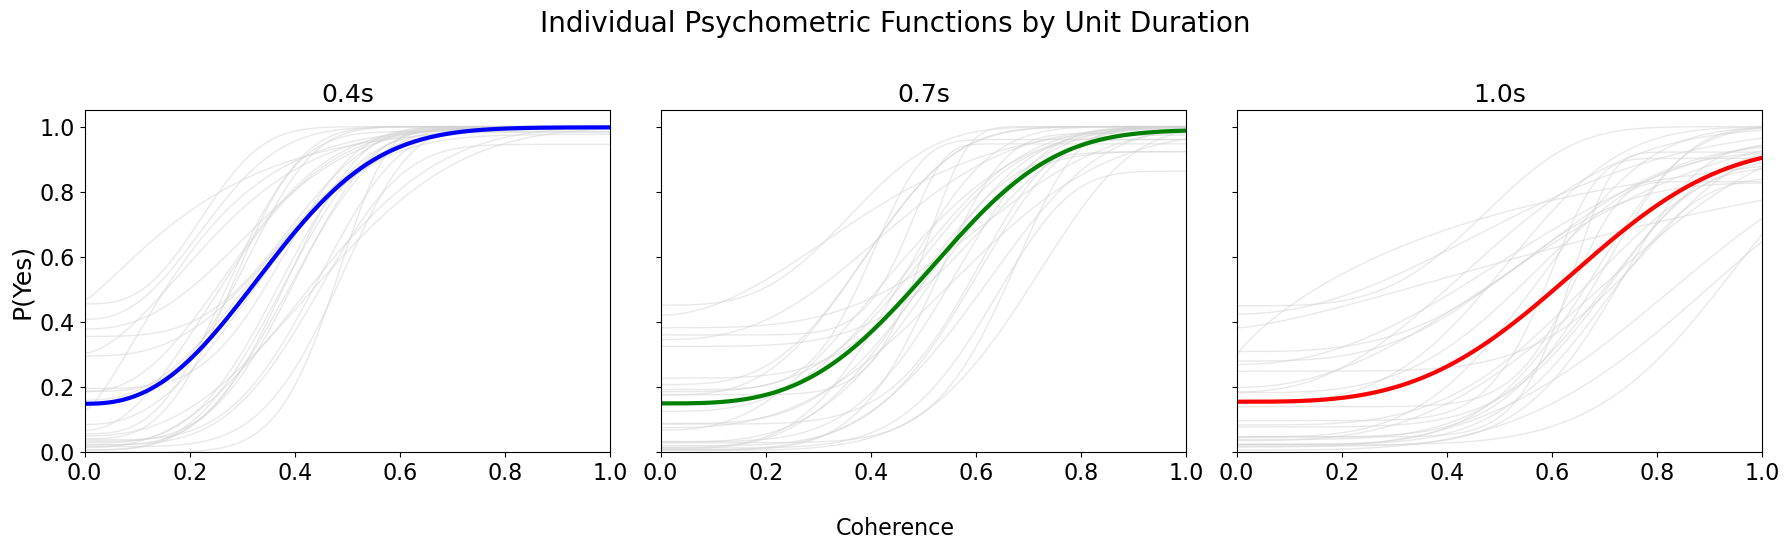

In [27]:
# here threshold correspond to the value passing the 50 percent yes
thresholds_50 = []  # Store (participant_id, unitdur, threshold_percentage)

unit_durations = [0.4, 0.7, 1.0]
colors = ['blue', 'green', 'red']
x_fit = np.linspace(0, 1, 200)
all_fit_results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)


# Loop through each subplot axis
for unitdur, color, ax in zip(unit_durations, colors, axes):
    filtered_df = summary_participant[summary_participant['unitdur'] == unitdur]
    participants = filtered_df['participant_id'].unique()
    fit_results = []

    # Plot individual fits
    for pid in participants:
        pdata = filtered_df[filtered_df['participant_id'] == pid]
        x_data = pdata['percentage'].values
        y_data = pdata['sum_yes'].values
        n_trials = pdata['n_trial'].values

        initial_guess = [0.5, 3.0, 0.0, 0.0]
        bounds = [(0.01, 1.0), (0.1, 10.0), (0.0, 0.5), (0.0, 0.5)]

        res = minimize(neg_log_likelihood, initial_guess, args=(x_data, n_trials, y_data),
                       bounds=bounds, method='powell')

        if res.success:
            alpha, beta, gamma, lambd = res.x
            fit_results.append({
                'participant_id': pid,
                'unitdur': unitdur,
                'alpha': alpha,
                'beta': beta,
                'gamma': gamma,
                'lambd': lambd
            })

            y_fit = weibull_psychometric(x_fit, alpha, beta, gamma, lambd)
            ax.plot(x_fit, y_fit, color='lightgray', alpha=0.5, linewidth=1)

            # --- Find threshold where y_fit crosses 0.5 ---
            threshold_index = np.argmax(y_fit > 0.5)
            threshold_percentage = x_fit[threshold_index]

            thresholds_50.append({
            'participant_id': pid,
            'unitdur': unitdur,
            'threshold_percentage': threshold_percentage
            })


            # if any(np.isclose(res.x, [b[0] for b in bounds]) | np.isclose(res.x, [b[1] for b in bounds])):
            #     print(f"Warning: parameter at bounds for unitdur {unitdur}, participant {pid}")


    # Store fits
    fit_df = pd.DataFrame(fit_results)
    all_fit_results.append(fit_df)

    # Group-level fit using summary
    group_data = summary_all[summary_all['unitdur'] == unitdur]
    x_data_group = group_data['percentage'].values
    y_data_group = group_data['n_yes'].values
    n_trials_group = group_data['n_trial'].values



    res_group = minimize(
        neg_log_likelihood,
        x0=[0.5, 3.0, 0.0, 0.0],
        args=(x_data_group, n_trials_group, y_data_group),
        bounds=[(0.01, 1.0), (0.1, 10.0), (0.0, 1), (0.0, 1)],
        method='powell'
    )


    if res_group.success:
        alpha_group, beta_group, gamma_group, lambd_group = res_group.x
        y_group_fit = weibull_psychometric(x_fit, alpha_group, beta_group, gamma_group, lambd_group)
        ax.plot(x_fit, y_group_fit, color=color, linewidth=3)

    ax.set_title(f'{unitdur}s', fontsize = 18)
    # ax.set_xlabel('Repetition Coherence', fontsize = 18)
    ax.tick_params(axis='both', labelsize=16)  # Adjust tick label size
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)

fig.text(0.5, -0.07, 'Coherence', ha='center', fontsize=16)
# Shared y-axis label
axes[0].set_ylabel('P(Yes)', fontsize=18)

plt.suptitle('Individual Psychometric Functions by Unit Duration', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

combined_fit_df = pd.concat(all_fit_results, ignore_index=True)


### unit duration comparison

In [28]:
summary_unitdur = df_det_clean.groupby(['unitdur', 'participant_id']).agg(
    mean_correct=('correct', 'mean'),
    std_correct=('correct', 'std'),
    n_correct = ('correct', 'sum'),
    n_trial = ('correct', 'count'),
).reset_index()

In [29]:
performance_summary_for_anova = df_det_clean.groupby(['unitdur', 'participant_id', 'percentage']).agg(
    mean_correct=('correct', 'mean'),
    std_correct=('correct', 'std'),
    n_correct = ('correct', 'sum'),
    n_trial = ('correct', 'count'),
).reset_index()

In [ ]:
# performance_summary_for_anova.to_csv('detection_performance_for_r.csv', index=False)

In [30]:
summary_unitdur['unitdur'] = summary_unitdur['unitdur'].astype(str)

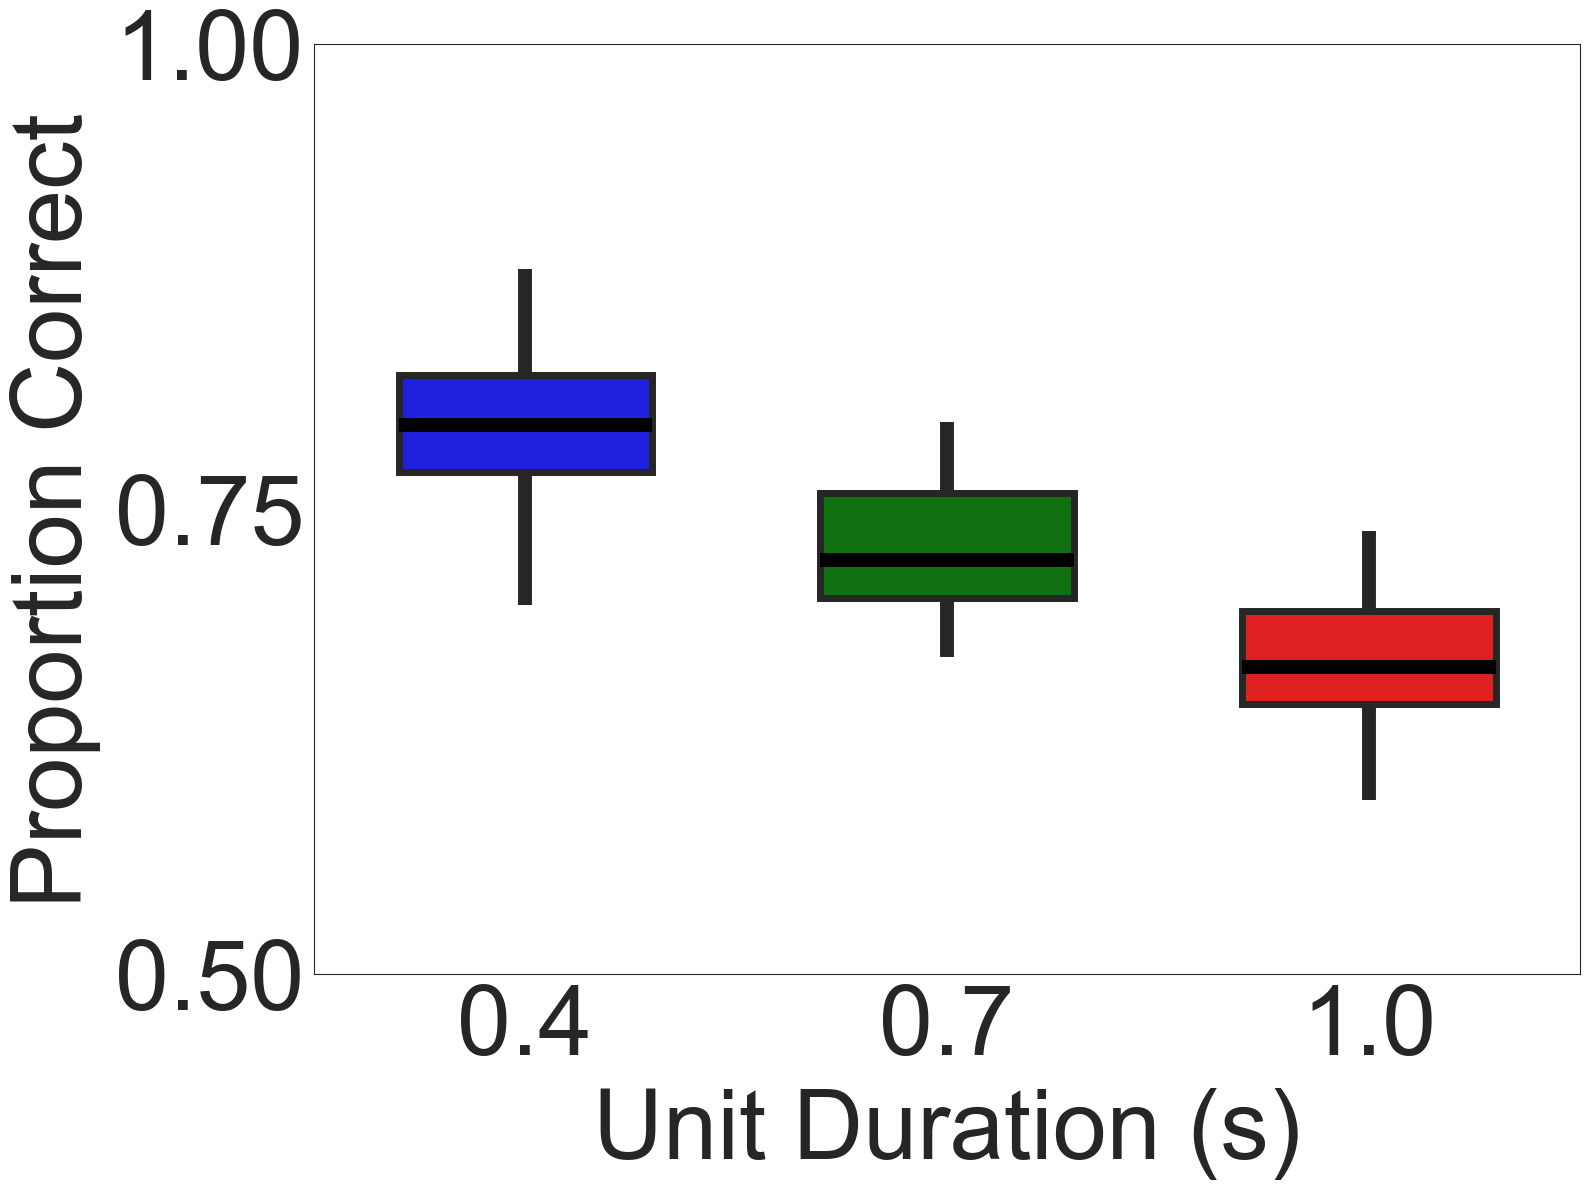

In [31]:
colors = {0.4: 'blue', 0.7: 'green', 1.0: 'red'}
colors_str = {str(k): v for k, v in colors.items()}

# Turn off Seaborn grid styling
sns.set_style("white")  # or "ticks"

# Create figure and axes manually so we can control the grid
fig, ax = plt.subplots(figsize=(16, 12))

# Boxplot
sns.boxplot(
    data=summary_unitdur,
    x='unitdur',
    y='mean_correct',
    palette=colors_str,
    width=0.6,
    ax=ax,
    boxprops=dict(linewidth=5),
    whiskerprops=dict(linewidth=10, solid_capstyle='butt'),  # Thick whiskers
    capprops=dict(visible=False),
    flierprops=dict(marker='', markersize=0),
    medianprops=dict(color='black', linewidth=10)
)

# # Overlay stripplot
# sns.stripplot(
#     data=threshold_df_tap,
#     x='unitdur',
#     y='threshold_percentage',
#     color='black',
#     alpha=0.6,
#     jitter=True,
#     ax=ax
# )

# Labels & Style
ax.set_xlabel('Unit Duration (s)', fontsize=70, labelpad= 10)
ax.set_ylabel('Proportion Correct', fontsize=70, labelpad=10)
# ax.set_title('Distribution of Alpha Parameters', fontsize=20)

ax.grid(False)
plt.xticks(fontsize=70)
plt.yticks([0.5, 0.75, 1], fontsize=70)
# Axis ticks
# ax.tick_params(axis='both', labelsize=16)
# plt.ylim([0,1])
plt.tight_layout()
plt.show()


In [32]:
threshold_df = pd.DataFrame(thresholds_50)

In [ ]:
# threshold_df.to_csv('threshold_50_detection_for_r.csv', index=False)

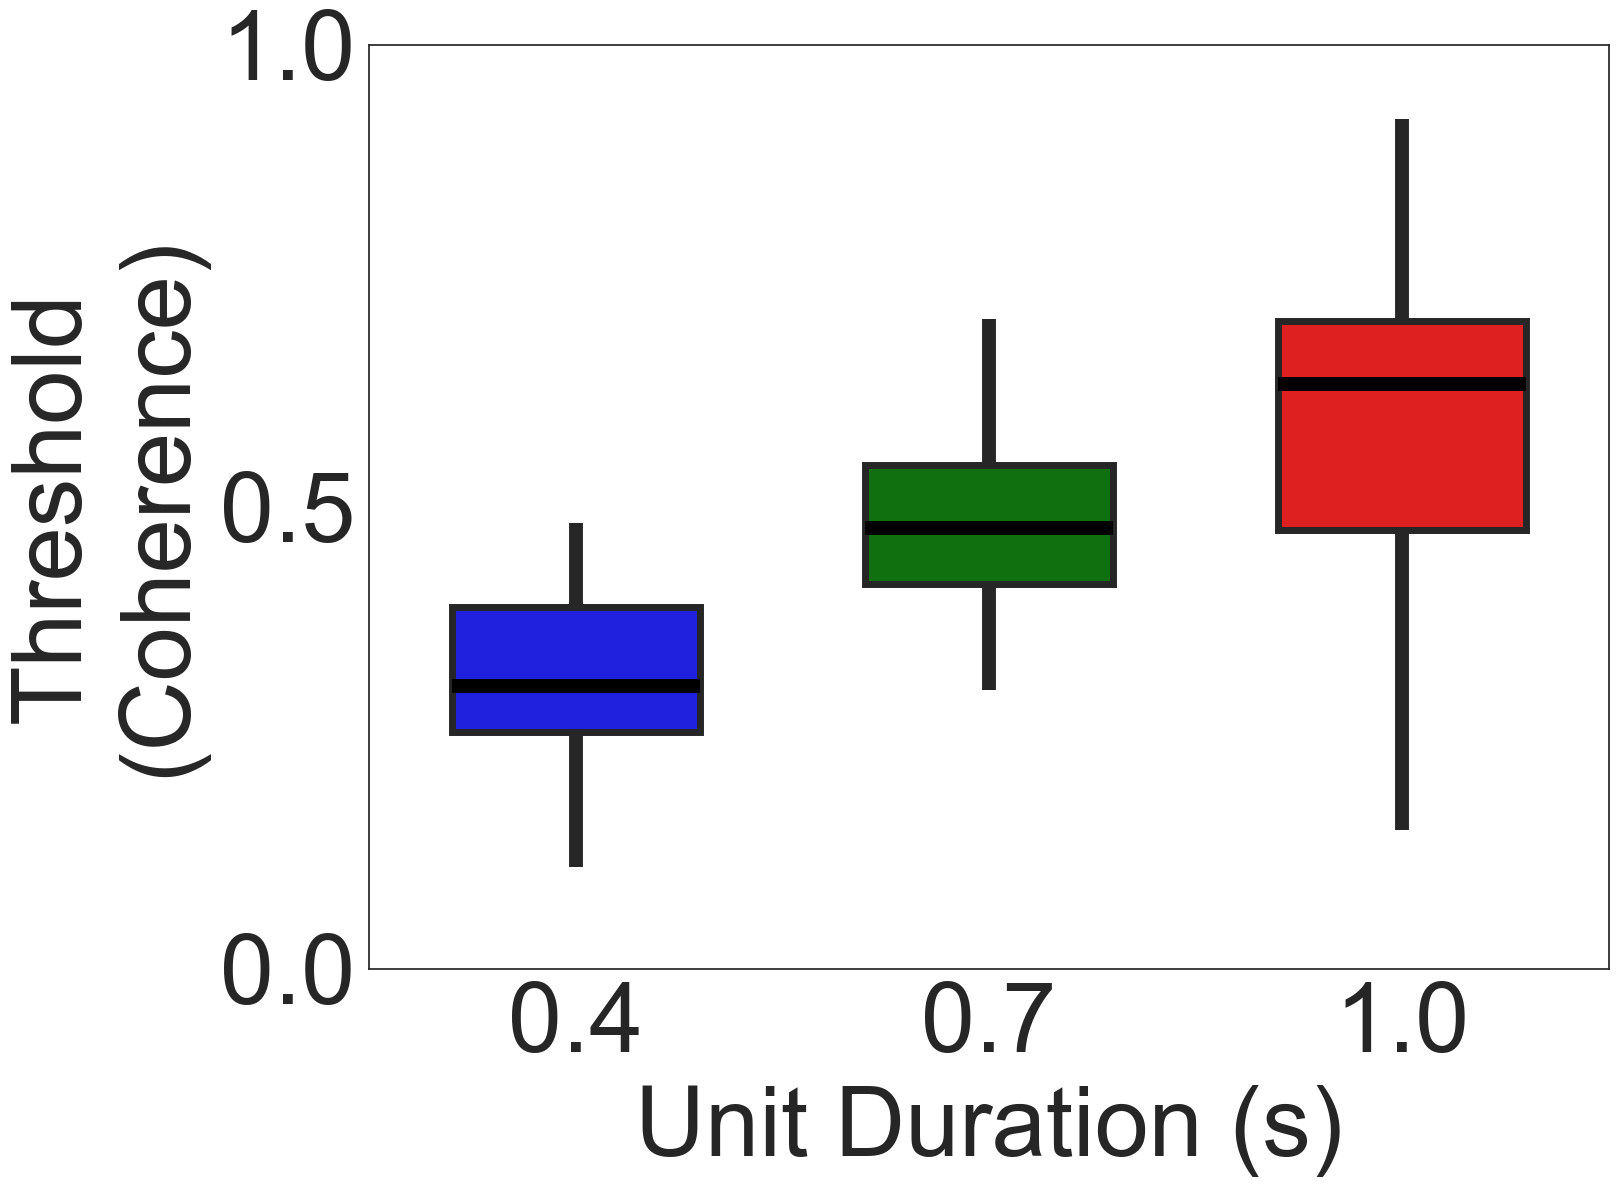

In [45]:
threshold_df_det = threshold_df.dropna(subset = ['threshold_percentage'])
# Convert to string for categorical plotting
threshold_df_det['unitdur'] = threshold_df_det['unitdur'].astype(str)

colors = {0.4: 'blue', 0.7: 'green', 1.0: 'red'}
colors_str = {str(k): v for k, v in colors.items()}

# Turn off Seaborn grid styling
sns.set_style("white")  # or "ticks"

# Create figure and axes manually so we can control the grid
fig, ax = plt.subplots(figsize=(16, 12))

# Boxplot
sns.boxplot(
    data=threshold_df_det,
    x='unitdur',
    y='threshold_percentage',
    palette=colors_str,
    width=0.6,
    ax=ax,
    boxprops=dict(linewidth=5),
    whiskerprops=dict(linewidth=10, solid_capstyle='butt'),  # Thick whiskers
    capprops=dict(visible=False),
    flierprops=dict(marker='', markersize=0),
    medianprops=dict(color='black', linewidth=10)
)

# # Overlay stripplot
# sns.stripplot(
#     data=alpha_df_det,
#     x='unitdur',
#     y='alpha',
#     color='black',
#     alpha=0.6,
#     jitter=True,
#     ax=ax
# )

# Labels & Style
ax.set_xlabel('Unit Duration (s)', fontsize=70, labelpad=10)
ax.set_ylabel('Threshold\n(Coherence)', fontsize=70, labelpad=10)
# ax.set_title('Distribution of Alpha Parameters', fontsize=20)

ax.grid(False)
plt.xticks(fontsize=70)
plt.yticks([0, 0.5, 1.0], fontsize=70)
# Axis ticks
# ax.tick_params(axis='both', labelsize=16)
plt.ylim([0,1])
# plt.tight_layout()
plt.show()

In [35]:
# Group by unit duration and compute mean and SEM
threshold_summary = (
    threshold_df.groupby('unitdur')
    .agg(mean_threshold=('threshold_percentage', 'mean'),
         std_threshold=('threshold_percentage', 'std'),
         n=('threshold_percentage', 'count'))
    .reset_index()
)

threshold_summary['sem_threshold'] = threshold_summary['std_threshold'] / threshold_summary['n']**0.5

In [36]:
# Step 2: Group and compute required metrics including MADs
participant_summary_ncycle = (
    df_det_no_outlier
    .groupby(['participant_id', 'percentage', 'unitdur', 'correct'])
    .agg(
        sum_correct=('correct', 'sum'),
        median_ncycle=('n_cycle', 'median'),
        median_rt=('rt', 'median'),
    )
    .reset_index()
)

In [ ]:
# participant_summary_ncycle.to_csv('n_cycle_for_r.csv', index=False)

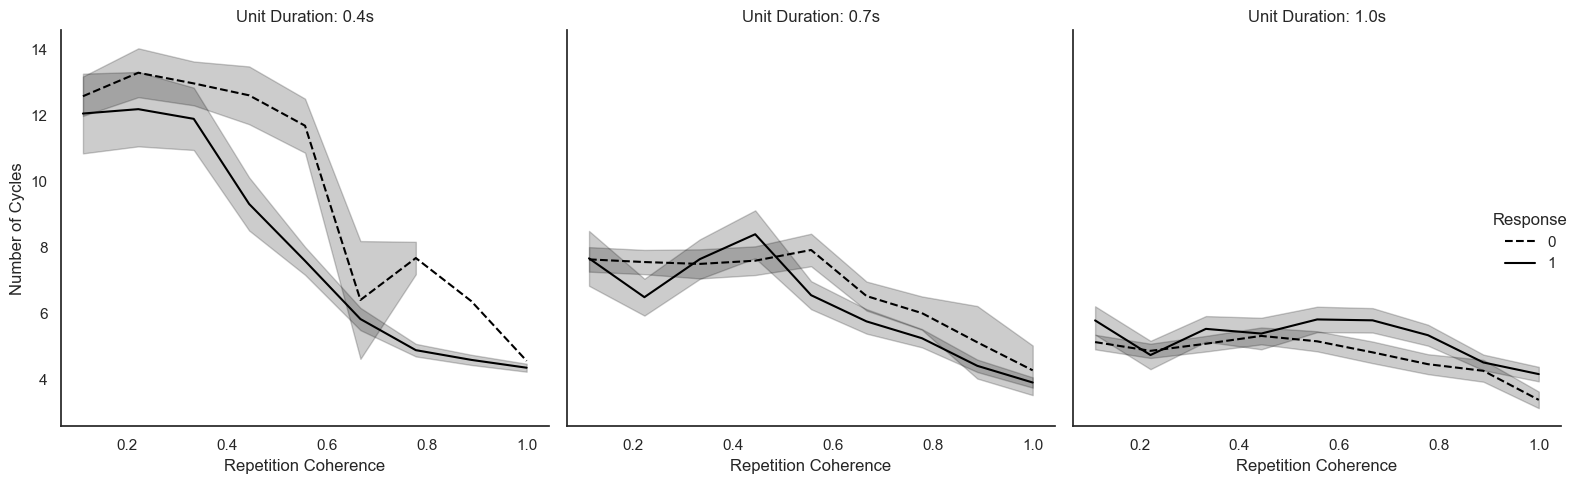

In [37]:
sns.set(style='white')

# Filter data
filtered_df = participant_summary_ncycle[participant_summary_ncycle['percentage'] > 0.1].copy()

# Convert unit_dur to categorical for ordering (optional)
filtered_df['unitdur'] = filtered_df['unitdur'].astype(float)

# Define color palette by unit duration
color_map = {0.4: 'blue', 0.7: 'green', 1.0: 'red'}

# Create FacetGrid: one subplot per unit duration
g = sns.FacetGrid(
    data=filtered_df,
    col='unitdur',
    col_order=[0.4, 0.7, 1.0],
    hue='correct',
    palette={0: 'black', 1: 'black'},  # same color, different line styles
    height=5,
    aspect=1
)

# Plotting function
def plot_lines(data, **kwargs):
    for correct_val, group in data.groupby('correct'):
        linestyle = '-' if correct_val == 1 else '--'
        sns.lineplot(
            data=group,
            x='percentage',
            y='median_ncycle',
            estimator='mean',
            errorbar='se',
            linestyle=linestyle,
            **kwargs
        )

# Map plot function to FacetGrid
g.map_dataframe(plot_lines)

# Adjust labels and titles
g.set_axis_labels("Repetition Coherence", "Number of Cycles")
g.set_titles("Unit Duration: {col_name}s")
g.add_legend(title="Response")

# Style
plt.tight_layout()
plt.show()


In [38]:
correct_trials = df_det_no_outlier[df_det_no_outlier['correct'] == 1]

In [39]:
# Step 1: Define a custom MAD function
def mad(series):
    return np.median(np.abs(series - np.median(series)))

# Step 2: Group and compute required metrics including MADs
participant_summary_correct_ncycle = (
    correct_trials
    .groupby(['participant_id', 'percentage', 'unitdur'])
    .agg(
        sum_correct=('correct', 'sum'),
        median_ncycle=('n_cycle', 'median'),
        mad_ncycle=('n_cycle', mad),
        median_rt=('rt', 'median'),
        mad_rt=('rt', mad)
    )
    .reset_index()
)

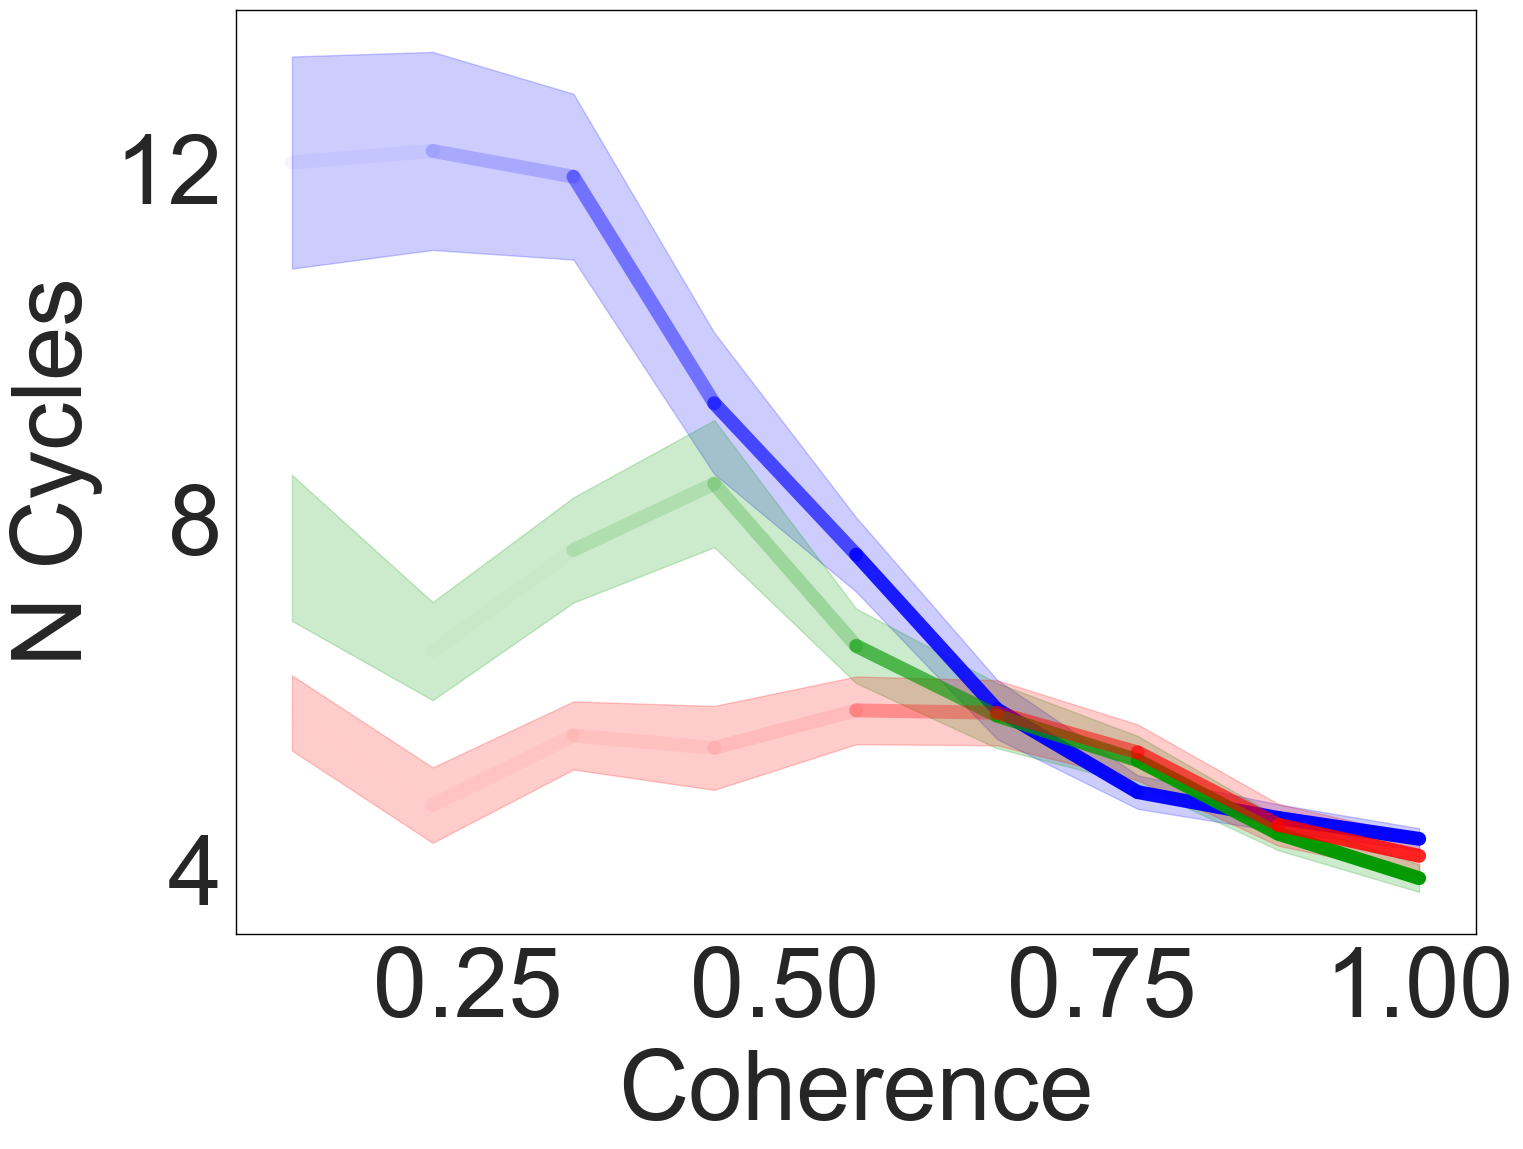

In [41]:
# Prepare data
plot_data = participant_summary_correct_ncycle[participant_summary_correct_ncycle['percentage'] >= 0.111].copy()
plot_data['percentage'] = plot_data['percentage'].round(3)
plot_data['unitdur'] = plot_data['unitdur'].astype(str)

# Compute mean and SEM
grouped = plot_data.groupby(['percentage', 'unitdur']).agg(
    mean_ncycle=('median_ncycle', 'mean'),
    sem_ncycle=('median_ncycle', sem),
    mean_correct=('sum_correct', 'mean')
).reset_index()

# Normalize correct globally for transparency (darker = more correct)
min_correct = grouped['mean_correct'].min()
max_correct = grouped['mean_correct'].max()
grouped['correct_norm'] = (grouped['mean_correct'] - min_correct) / (max_correct - min_correct)

# Define base colors
base_colors = {'0.4': (0, 0, 1), '0.7': (0, 0.6, 0), '1.0': (1, 0, 0)}  # Blue, Green, Red

# Start plot
fig, ax = plt.subplots(figsize=(16, 12), facecolor='white')
ax.set_facecolor('white')

# Plot per duration
for dur in ['0.4', '0.7', '1.0']:
    subset = grouped[grouped['unitdur'] == dur].sort_values('percentage')
    
    # Plot SEM shaded region
    x_vals = subset['percentage']
    y_vals = subset['mean_ncycle']
    y_err = subset['sem_ncycle']
    ax.fill_between(x_vals, y_vals - y_err, y_vals + y_err,
                    color=base_colors[dur], alpha=0.2)
    
    # Plot each line segment with color shading
    for i in range(len(subset) - 1):
        x_pair = x_vals.iloc[i:i+2]
        y_pair = y_vals.iloc[i:i+2]
        alpha = subset['correct_norm'].iloc[i]
        ax.plot(x_pair, y_pair, color=base_colors[dur], alpha=alpha, linewidth=10)
    
    # Add circle markers for means
    # ax.plot(x_vals, y_vals, 'o', color=base_colors[dur], markersize=6, alpha=0.9)

# Axes formatting
ax.set_xlabel('Coherence', fontsize=70, labelpad=10)
ax.set_ylabel('N Cycles', fontsize=70, labelpad=8)

# Axes appearance
for spine in ['left', 'bottom', 'top', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(1)

# Add dashed vertical reference line at x = 0.556
# ax.axvline(x=0.556, color='gray', linestyle='--', linewidth=10, alpha=0.8)
# Set custom ticks
# ax.set_xticks([4, 8, 12])
ax.set_yticks([4, 8, 12])  # Adjust based on your actual y range

# Tick formatting
ax.tick_params(axis='x', labelsize=70)
ax.tick_params(axis='y', labelsize=70)


# ax.tick_params(axis='both', which='both', length=5, width=1, color='black', labelsize=16)
ax.grid(False)

# plt.tight_layout()
plt.show()


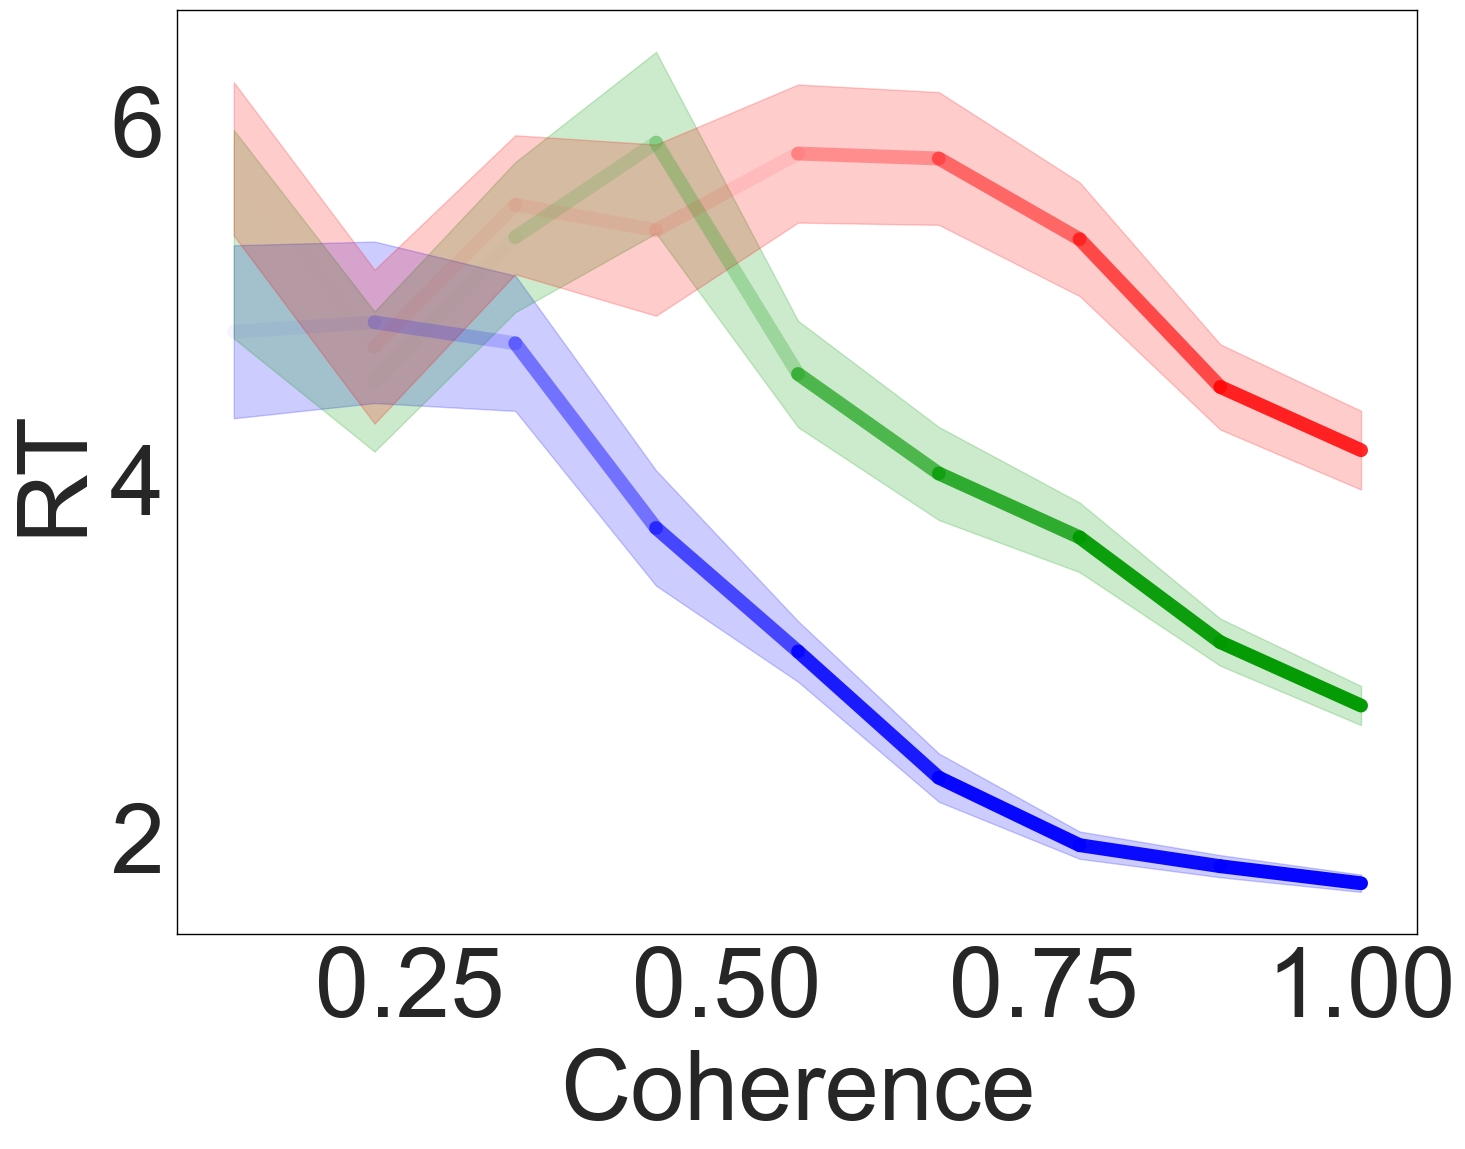

In [42]:
# Compute mean and SEM
grouped = plot_data.groupby(['percentage', 'unitdur']).agg(
    mean_rt=('median_rt', 'mean'),
    sem_rt=('median_rt', sem),
    mean_correct=('sum_correct', 'mean')
).reset_index()

# Normalize correct globally for transparency (darker = more correct)
min_correct = grouped['mean_correct'].min()
max_correct = grouped['mean_correct'].max()
grouped['correct_norm'] = (grouped['mean_correct'] - min_correct) / (max_correct - min_correct)

# Define base colors
base_colors = {'0.4': (0, 0, 1), '0.7': (0, 0.6, 0), '1.0': (1, 0, 0)}  # Blue, Green, Red

# Start plot
fig, ax = plt.subplots(figsize=(16, 12), facecolor='white')
ax.set_facecolor('white')

# Plot per duration
for dur in ['0.4', '0.7', '1.0']:
    subset = grouped[grouped['unitdur'] == dur].sort_values('percentage')
    
    # Plot SEM shaded region
    x_vals = subset['percentage']
    y_vals = subset['mean_rt']
    y_err = subset['sem_rt']
    ax.fill_between(x_vals, y_vals - y_err, y_vals + y_err,
                    color=base_colors[dur], alpha=0.2)
    
    # Plot each line segment with color shading
    for i in range(len(subset) - 1):
        x_pair = x_vals.iloc[i:i+2]
        y_pair = y_vals.iloc[i:i+2]
        alpha = subset['correct_norm'].iloc[i]
        ax.plot(x_pair, y_pair, color=base_colors[dur], alpha=alpha, linewidth=10)
    
    # Add circle markers for means
    # ax.plot(x_vals, y_vals, 'o', color=base_colors[dur], markersize=6, alpha=0.9)

# Axes formatting
ax.set_xlabel('Coherence', fontsize=70, labelpad=10)
ax.set_ylabel('RT', fontsize=70, labelpad=8)

# Axes appearance
for spine in ['left', 'bottom', 'top', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(1)

# Add dashed vertical reference line at x = 0.556
# ax.axvline(x=0.556, color='gray', linestyle='--', linewidth=10, alpha=0.8)

# Set custom ticks
# ax.set_xticks([4, 8, 12])
ax.set_yticks([2, 4, 6])  # Adjust based on your actual y range

# Tick formatting
ax.tick_params(axis='x', labelsize=70)
ax.tick_params(axis='y', labelsize=70)

ax.grid(False)

# plt.tight_layout()
plt.show()


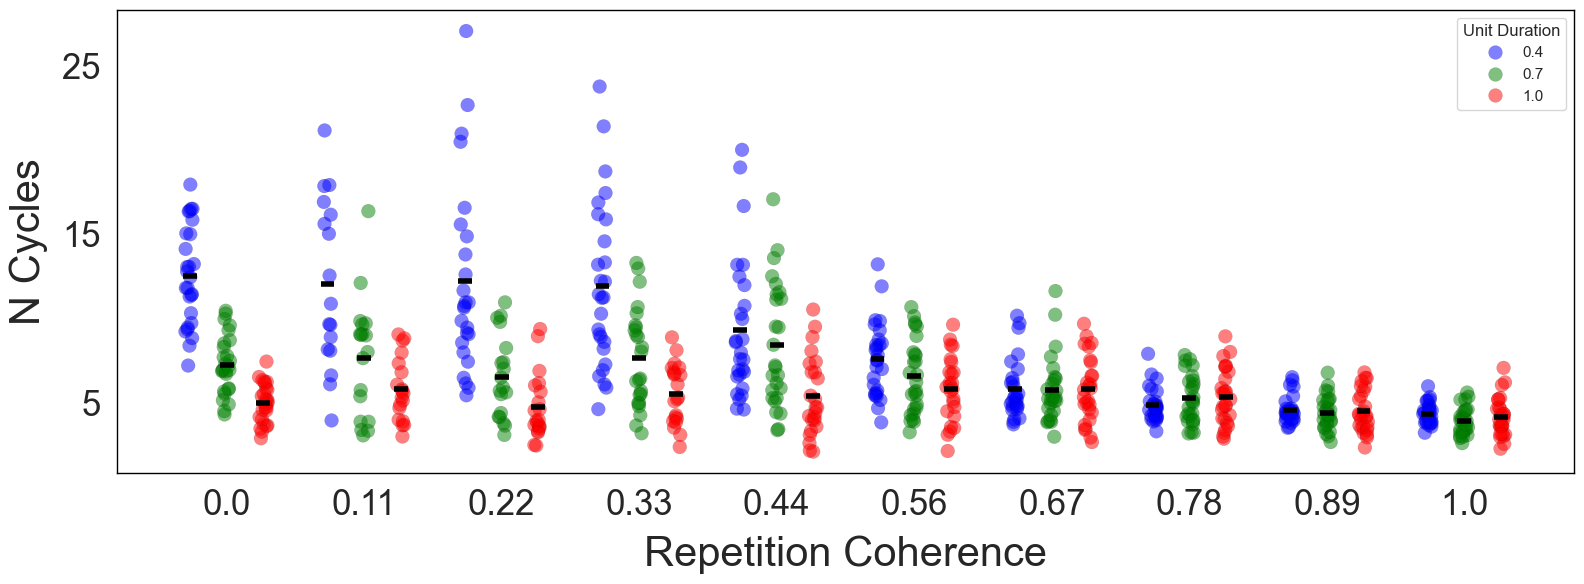

In [43]:
plot_data = participant_summary_correct_ncycle.copy()
plot_data['percentage'] = plot_data['percentage'].round(2)
plot_data['unitdur'] = plot_data['unitdur'].astype(str)


# Calculate group means for median_ncycle across individuals
group_means = plot_data.groupby(['percentage', 'unitdur'])['median_ncycle'].mean().reset_index()

colors = {0.4: 'blue', 0.7: 'green', 1.0: 'red'}
colors_str = {str(k): v for k, v in colors.items()}
plt.figure(figsize=(16, 6))
ax = sns.stripplot(
    data=plot_data,
    x='percentage',
    y='median_ncycle',
    hue='unitdur',
    marker='o',
    dodge=True,
    palette=colors_str,
    edgecolor='black',
    linewidth=0.1,
    size=10,
    alpha = 0.5
)

# Add horizontal lines (ticks) for group means — plotted AFTER stripplot for visibility
unitdur_order = sorted(plot_data['unitdur'].unique())
percentage_order = sorted(plot_data['percentage'].unique())
n_unitdur = len(unitdur_order)
xtick_pos = np.arange(len(percentage_order))
dodge_width = 0.8
single_width = dodge_width / n_unitdur

for _, row in group_means.iterrows():
    base_x = xtick_pos[percentage_order.index(row['percentage'])]
    unitdur_idx = unitdur_order.index(row['unitdur'])
    x = base_x - dodge_width/2 + single_width/2 + unitdur_idx * single_width
    y = row['median_ncycle']
    # Plot the line on top
    ax.hlines(y, x - 0.05, x + 0.05, colors='black', linewidth=4, zorder=10)  # higher zorder = on top

# Set white background and black spines
ax.set_facecolor('white')
plt.gcf().set_facecolor('white')

for spine in ['left', 'bottom', 'top', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(1)

# Increase tick size and labels
ax.tick_params(axis='both', which='major', length=8, width=1.5, labelsize=16, color='black')

# Increase axis label font size
ax.set_xlabel('Repetition Coherence', fontsize=30, labelpad=10)
ax.set_ylabel('N Cycles', fontsize=30, labelpad=10)

# Clean up the legend (remove duplicates)
handles, labels = ax.get_legend_handles_labels()
n_unique = plot_data['unitdur'].nunique()
plt.legend(handles[:n_unique], labels[:n_unique], title='Unit Duration')

# Set custom ticks
# ax.set_xticks([4, 8, 12])
ax.set_yticks([5, 15, 25])  # Adjust based on your actual y range
# ax.set_xticks([0, 0.11, 0.22, 0.33, 0.44, 0.56, 0.67, 0.78, 0.89, 1])  # Adjust based on your actual y range
# Tick formatting
ax.tick_params(axis='x', labelsize=25)
ax.tick_params(axis='y', labelsize=25)

# Remove grid lines
ax.grid(False)

plt.tight_layout()
plt.show()


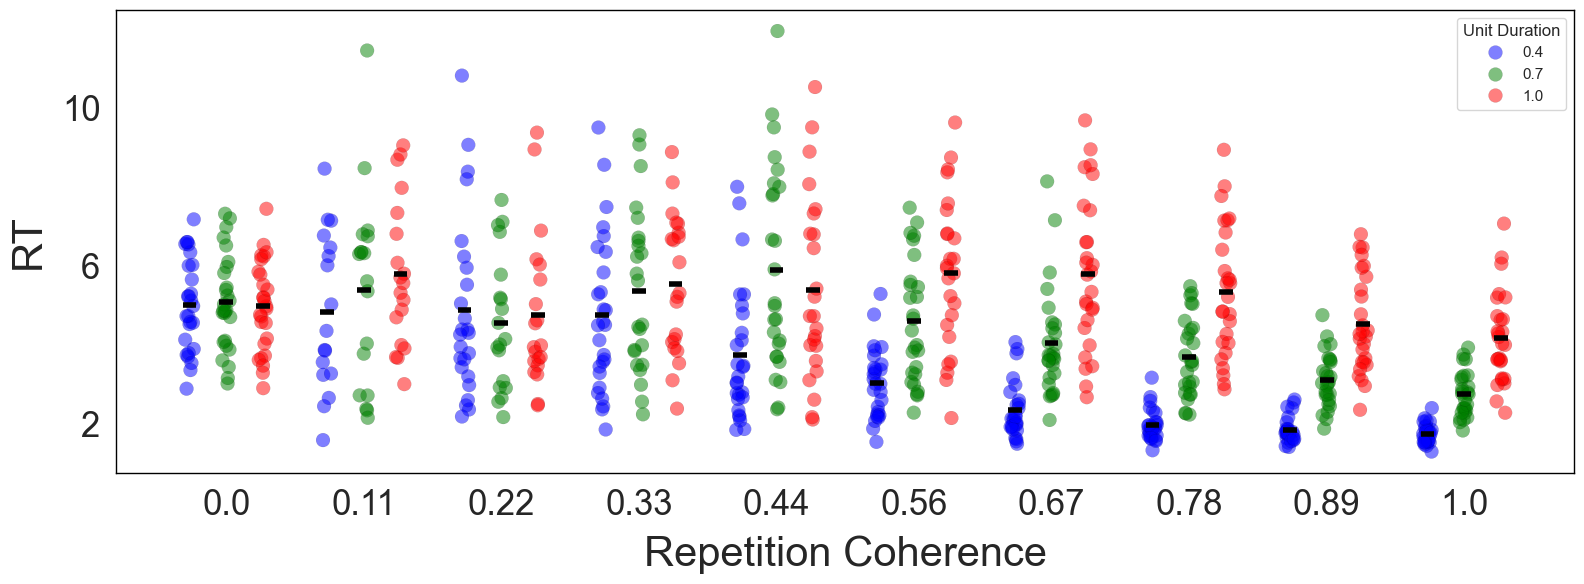

In [44]:
plot_data = participant_summary_correct_ncycle.copy()
plot_data['percentage'] = plot_data['percentage'].round(2)
plot_data['unitdur'] = plot_data['unitdur'].astype(str)

# Calculate group means for median_ncycle across individuals
group_means = plot_data.groupby(['percentage', 'unitdur'])['median_rt'].mean().reset_index()

colors = {0.4: 'blue', 0.7: 'green', 1.0: 'red'}
colors_str = {str(k): v for k, v in colors.items()}
plt.figure(figsize=(16, 6))
ax = sns.stripplot(
    data=plot_data,
    x='percentage',
    y='median_rt',
    hue='unitdur',
    marker='o',
    dodge=True,
    palette=colors_str,
    edgecolor='black',
    linewidth=0.1,
    size=10,
    alpha = 0.5
)

# Add horizontal lines (ticks) for group means — plotted AFTER stripplot for visibility
unitdur_order = sorted(plot_data['unitdur'].unique())
percentage_order = sorted(plot_data['percentage'].unique())
n_unitdur = len(unitdur_order)
xtick_pos = np.arange(len(percentage_order))
dodge_width = 0.8
single_width = dodge_width / n_unitdur

for _, row in group_means.iterrows():
    base_x = xtick_pos[percentage_order.index(row['percentage'])]
    unitdur_idx = unitdur_order.index(row['unitdur'])
    x = base_x - dodge_width/2 + single_width/2 + unitdur_idx * single_width
    y = row['median_rt']
    # Plot the line on top
    ax.hlines(y, x - 0.05, x + 0.05, colors='black', linewidth=4, zorder=10)  # higher zorder = on top

# Set white background and black spines
ax.set_facecolor('white')
plt.gcf().set_facecolor('white')

for spine in ['left', 'bottom', 'top', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(1)

# Increase tick size and labels
ax.tick_params(axis='both', which='major', length=8, width=1.5, labelsize=16, color='black')

# Increase axis label font size
ax.set_xlabel('Repetition Coherence', fontsize=30, labelpad=10)
ax.set_ylabel('RT', fontsize=30, labelpad=10)

# Clean up the legend (remove duplicates)
handles, labels = ax.get_legend_handles_labels()
n_unique = plot_data['unitdur'].nunique()
plt.legend(handles[:n_unique], labels[:n_unique], title='Unit Duration')

# Set custom ticks
# ax.set_xticks([4, 8, 12])
ax.set_yticks([2, 6, 10])  # Adjust based on your actual y range
# ax.set_xticks([0, 0.11, 0.22, 0.33, 0.44, 0.56, 0.67, 0.78, 0.89, 1])  # Adjust based on your actual y range
# Tick formatting
ax.tick_params(axis='x', labelsize=25)
ax.tick_params(axis='y', labelsize=25)

# Remove grid lines
ax.grid(False)

plt.tight_layout()
plt.show()
